In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

meta_path = "C:/Project/resource-recommender/data/raw/container_meta.csv"
usage_path = "C:/Project/resource-recommender/data/raw/container_usage.csv"

meta_nrows = 500000
usage_nrows = 1000000
lags = 3
lookback = 5
grid_sample_size = 50000
horizon_minutes = 10 # эта переменная регулирует горизонт прогноза в минутах!!!
cpu_safety_margin = 1.20
ram_safety_margin = 1.15

print(f"Готовлю данные и перевожу временной ряд в окна по {horizon_minutes} минут")

meta = pd.read_csv(
    meta_path,
    header=None,
    names=[
        "container_id",
        "machine_id",
        "time_stamp",
        "app_du",
        "status",
        "cpu_request",
        "cpu_limit",
        "mem_size"
    ],
    nrows=meta_nrows
)

usage = pd.read_csv(
    usage_path,
    header=None,
    names=[
        "container_id",
        "machine_id",
        "time_stamp",
        "cpu_util_percent",
        "mem_util_percent",
        "cpi",
        "mem_gps",
        "mpki",
        "net_in",
        "net_out",
        "disk_io_percent"
    ],
    nrows=usage_nrows
)

# Удаление строк с пропущенными значениями
meta = meta.dropna(subset=["container_id", "machine_id", "time_stamp", "cpu_request", "cpu_limit", "mem_size"]).copy()
usage = usage.dropna(subset=["container_id", "machine_id", "time_stamp", "cpu_util_percent", "mem_util_percent"]).copy()

# Удаление дубликатов
meta = meta.drop_duplicates(subset=["container_id", "machine_id", "time_stamp", "cpu_request", "cpu_limit", "mem_size"])
usage = usage.drop_duplicates(subset=["container_id", "machine_id", "time_stamp"])

# Фильтрация от аномальных значений
meta = meta[
    (meta["cpu_request"] > 0) &
    (meta["cpu_limit"] > 0) &
    (meta["mem_size"] > 0)
].copy()

usage = usage[
    usage["cpu_util_percent"].between(0, 100) &
    usage["mem_util_percent"].between(0, 100)
].copy()

# Преобразование в числовой формат с обработкой ошибок 
meta["time_stamp"] = pd.to_numeric(meta["time_stamp"], errors="coerce")
usage["time_stamp"] = pd.to_numeric(usage["time_stamp"], errors="coerce")

# Удаление строк с пропущенными значениями
meta = meta.dropna(subset=["time_stamp"]).copy()
usage = usage.dropna(subset=["time_stamp"]).copy()

# Приведение к целочисленному типу
meta["time_stamp"] = meta["time_stamp"].astype(np.int64)
usage["time_stamp"] = usage["time_stamp"].astype(np.int64)

# Подготовка DataFrame для слияния
meta_for_merge = meta[["container_id", "machine_id", "time_stamp", "cpu_request", "cpu_limit", "mem_size"]].copy()

# сортирует строки по трём колонкам в указанном порядке: time_stamp (по возрастанию времени); 
#                                                        container_id (при одинаковых временных метках); 
#                                                        machine_id (если совпадают и время, и контейнер).
meta_for_merge = meta_for_merge.sort_values(["time_stamp", "container_id", "machine_id"]).reset_index(drop=True)
# ###(хотелось бы увидеть распределение cpu и ram во времени)###

# Подготовка и сортировка
usage_for_merge = usage.copy()

usage_for_merge = usage_for_merge.sort_values(["time_stamp", "container_id", "machine_id"]).reset_index(drop=True)

# слияние таблиц выполняется по временной метке
df_raw = pd.merge_asof(
    usage_for_merge,
    meta_for_merge,
    on="time_stamp",
    by=["container_id", "machine_id"],
    direction="backward"
)

# удаление строк, где не удалось найти соответствующие метаданные (т.е. пропущенные значения в колонках cpu_request, cpu_limit, mem_size)
df_raw = df_raw.dropna(subset=["cpu_request", "cpu_limit", "mem_size"]).copy()
df_raw = df_raw.sort_values(["container_id", "time_stamp"]).reset_index(drop=True)

# рассчитываем временное окно в секундах
horizon_seconds = horizon_minutes * 60
df_raw["time_window"] = (df_raw["time_stamp"] // horizon_seconds) * horizon_seconds

# агрегируем данные по окнам для каждого контейнера
window_df = (
    df_raw
    .groupby(["container_id", "time_window"], as_index=False)
    .agg(
        machine_id=("machine_id", "last"),
        cpu_util_mean=("cpu_util_percent", "mean"),
        cpu_util_max=("cpu_util_percent", "max"),
        cpu_util_std=("cpu_util_percent", "std"),
        mem_util_mean=("mem_util_percent", "mean"),
        mem_util_max=("mem_util_percent", "max"),
        mem_util_std=("mem_util_percent", "std"),
        cpu_request=("cpu_request", "last"),
        cpu_limit=("cpu_limit", "last"),
        mem_size=("mem_size", "last"),
        samples_in_window=("cpu_util_percent", "size")
    )
)

# Заполняем пропуски в стандартных отклонениях нулями (т.е. считаем, что если std не посчиталось, то в окне была стабильная нагрузка)
window_df["cpu_util_std"] = window_df["cpu_util_std"].fillna(0)
window_df["mem_util_std"] = window_df["mem_util_std"].fillna(0)

# сортируем по контейнеру и окну, чтобы гарантировать правильный порядок для последующих операций
window_df = window_df.sort_values(["container_id", "time_window"]).reset_index(drop=True)

# добавляем циклические признаки для времени суток и дня недели
window_df["relative_hour"] = ((window_df["time_window"] // 3600) % 24).astype(int)
window_df["relative_day_cycle"] = ((window_df["time_window"] // 86400) % 7).astype(int)

# добавляем лаги, скользящие статистики и дельты для CPU и RAM с shift(1), чтобы не допустить утечки данных из будущего в прошлое
for i in range(1, lags + 1):
    window_df[f"cpu_lag_{i}"] = window_df.groupby("container_id")["cpu_util_mean"].shift(i)
    window_df[f"mem_lag_{i}"] = window_df.groupby("container_id")["mem_util_mean"].shift(i)

window_df["cpu_roll_mean_3"] = window_df.groupby("container_id")["cpu_util_mean"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
window_df["mem_roll_mean_3"] = window_df.groupby("container_id")["mem_util_mean"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
window_df["cpu_roll_std_3"] = window_df.groupby("container_id")["cpu_util_mean"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
window_df["mem_roll_std_3"] = window_df.groupby("container_id")["mem_util_mean"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())

window_df["cpu_delta_1"] = window_df.groupby("container_id")["cpu_util_mean"].transform(lambda x: x.diff().shift(1))
window_df["mem_delta_1"] = window_df.groupby("container_id")["mem_util_mean"].transform(lambda x: x.diff().shift(1))

# добавляем признаки соотношений ресурсов, которые могут помочь модели понять, насколько близко контейнер к своим лимитам и насколько эффективно он использует выделенные ресурсы
window_df["cpu_request_limit_ratio"] = window_df["cpu_request"] / window_df["cpu_limit"]
window_df["cpu_limit_mem_ratio"] = window_df["cpu_limit"] / window_df["mem_size"]
window_df["cpu_request_mem_ratio"] = window_df["cpu_request"] / window_df["mem_size"]

# добавляем таргеты - среднюю загрузку CPU и RAM в следующем окне для каждого контейнера, используя shift(-1) для получения значения из будущего окна
window_df["cpu_target"] = window_df.groupby("container_id")["cpu_util_mean"].shift(-1)
window_df["mem_target"] = window_df.groupby("container_id")["mem_util_mean"].shift(-1)

# удаляем строки с пропущенными таргетами, так как они не могут быть использованы для обучения модели
window_df = window_df.replace([np.inf, -np.inf], np.nan)

# определяем список признаков для модели
feature_cols = [
    "cpu_util_mean", "cpu_util_max", "cpu_util_std",
    "mem_util_mean", "mem_util_max", "mem_util_std",
    "cpu_lag_1", "cpu_lag_2", "cpu_lag_3",
    "mem_lag_1", "mem_lag_2", "mem_lag_3",
    "cpu_roll_mean_3", "mem_roll_mean_3",
    "cpu_roll_std_3", "mem_roll_std_3",
    "cpu_delta_1", "mem_delta_1",
    "cpu_request", "cpu_limit", "mem_size",
    "cpu_request_limit_ratio", "cpu_limit_mem_ratio", "cpu_request_mem_ratio",
    "relative_hour", "relative_day_cycle", "samples_in_window"
]

# формируем финальный DataFrame для обучения моделей, удаляя строки с пропущенными значениями в признаках и таргете, и сортируя по времени для корректного разбиения на train/val/test
df_model = window_df[["container_id", "machine_id", "time_window"] + feature_cols + ["cpu_target", "mem_target"]].copy()
df_model = df_model.dropna(subset=feature_cols + ["cpu_target", "mem_target"]).copy()
df_model = df_model.sort_values(["time_window", "container_id"]).reset_index(drop=True)
df_model["row_id"] = np.arange(len(df_model))

# Выбор 70% для train и 15% для val обусловлен желанием иметь достаточно данных для обучения модели на разнообразных временных окнах, при этом оставляя достаточно данных для валидации и тестирования
q_train = df_model["time_window"].quantile(0.70)
q_val = df_model["time_window"].quantile(0.85)

# разбиение на train/val/test по временным окнам, чтобы гарантировать отсутствие утечки данных из будущего в прошлое
train_df = df_model[df_model["time_window"] < q_train].copy()
val_df = df_model[(df_model["time_window"] >= q_train) & (df_model["time_window"] < q_val)].copy()
test_df = df_model[df_model["time_window"] >= q_val].copy()

print("Размер train:", train_df.shape)
print("Размер val:", val_df.shape)
print("Размер test:", test_df.shape)

# подготовка данных для табличных моделей - выделение признаков и таргетов
X_train_df = train_df[feature_cols].copy()
X_val_df = val_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()

y_cpu_train = train_df["cpu_target"].to_numpy()
y_mem_train = train_df["mem_target"].to_numpy()
y_cpu_val = val_df["cpu_target"].to_numpy()
y_mem_val = val_df["mem_target"].to_numpy()
y_cpu_test = test_df["cpu_target"].to_numpy()
y_mem_test = test_df["mem_target"].to_numpy()

# стандартизация признаков для табличных моделей, чтобы улучшить сходимость и производительность моделей
scaler = StandardScaler()
X_train_scaled_df = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=feature_cols,
    index=train_df.index
)
X_val_scaled_df = pd.DataFrame(
    scaler.transform(X_val_df),
    columns=feature_cols,
    index=val_df.index
)
X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=feature_cols,
    index=test_df.index
)

# для подбора гиперпараметров используем только часть обучающего набора, чтобы ускорить процесс, при этом сохраняя достаточно данных для надежной оценки моделей на кросс-валидации
gs_sample_size = min(grid_sample_size, len(X_train_scaled_df))
gs_idx = np.linspace(0, len(X_train_scaled_df) - 1, num=gs_sample_size, dtype=int)

# формируем подвыборку для GridSearchCV, чтобы ускорить подбор гиперпараметров, при этом сохраняя репрезентативность данных для надежной оценки моделей на кросс-валидации
X_train_gs_df = X_train_scaled_df.iloc[gs_idx].copy()
y_cpu_train_gs = train_df.iloc[gs_idx]["cpu_target"].to_numpy()
y_mem_train_gs = train_df.iloc[gs_idx]["mem_target"].to_numpy()

# используем TimeSeriesSplit для кросс-валидации, чтобы гарантировать, что модели обучаются на данных из прошлого и тестируются на данных из будущего, что соответствует реальной задаче прогнозирования временных рядов
tscv = TimeSeriesSplit(n_splits=3)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

lgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, -1],
    "learning_rate": [0.05, 0.1]
}

print("Подбираю XGBoost для CPU")
xgb_grid_cpu = GridSearchCV(
    xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ),
    xgb_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
xgb_grid_cpu.fit(X_train_gs_df, y_cpu_train_gs)

print("Подбираю XGBoost для RAM")
xgb_grid_mem = GridSearchCV(
    xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ),
    xgb_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
xgb_grid_mem.fit(X_train_gs_df, y_mem_train_gs)

print("Подбираю LightGBM для CPU")
lgb_grid_cpu = GridSearchCV(
    lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),
    lgb_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
lgb_grid_cpu.fit(X_train_gs_df, y_cpu_train_gs)

print("Подбираю LightGBM для RAM")
lgb_grid_mem = GridSearchCV(
    lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),
    lgb_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
lgb_grid_mem.fit(X_train_gs_df, y_mem_train_gs)

# для LSTM нам нужно построить последовательности из временных окон для каждого контейнера, чтобы модель могла учиться на динамике изменения загрузки во времени, а не только на статических признаках текущего окна
def build_sequences(frame, seq_cols, lookback_value):
    frame = frame.sort_values(["container_id", "time_window"]).reset_index(drop=True)

    X_seq = []
    y_cpu = []
    y_mem = []
    row_ids = []

    for _, group in frame.groupby("container_id", sort=False):
        values = group[seq_cols].to_numpy(dtype=np.float32)
        cpu_targets = group["cpu_target"].to_numpy(dtype=np.float32)
        mem_targets = group["mem_target"].to_numpy(dtype=np.float32)
        ids = group["row_id"].to_numpy()

        if len(group) < lookback_value:
            continue

        for i in range(lookback_value - 1, len(group)):
            X_seq.append(values[i - lookback_value + 1:i + 1])
            y_cpu.append(cpu_targets[i])
            y_mem.append(mem_targets[i])
            row_ids.append(ids[i])

    X_seq = np.array(X_seq, dtype=np.float32)
    y_cpu = np.array(y_cpu, dtype=np.float32)
    y_mem = np.array(y_mem, dtype=np.float32)
    row_ids = np.array(row_ids)

    order = np.argsort(row_ids)
    return X_seq[order], y_cpu[order], y_mem[order], row_ids[order]

seq_cols = [
    "cpu_util_mean", "cpu_util_max", "cpu_util_std",
    "mem_util_mean", "mem_util_max", "mem_util_std",
    "cpu_request", "cpu_limit", "mem_size",
    "relative_hour", "relative_day_cycle"
]

# построение последовательностей для LSTM, где каждая последовательность представляет собой набор из lookback_value окон для одного контейнера, а таргетом является загрузка в следующем окне после этих lookback_value окон
X_seq_all, y_seq_cpu_all, y_seq_mem_all, seq_row_ids_all = build_sequences(df_model, seq_cols, lookback)

# сопоставляем row_id из последовательностей с row_id в train/val/test, чтобы корректно разбить данные для LSTM по тем же временным окнам, что и для табличных моделей, и избежать утечки данных из будущего в прошлое
train_row_ids = train_df["row_id"].to_numpy()
val_row_ids = val_df["row_id"].to_numpy()
test_row_ids = test_df["row_id"].to_numpy()

# создаем маски для train/val/test на основе row_id, чтобы выделить соответствующие последовательности для обучения и оценки LSTM, гарантируя, что данные для каждой модели соответствуют одному и тому же временному разбиению
seq_train_mask = np.isin(seq_row_ids_all, train_row_ids)
seq_val_mask = np.isin(seq_row_ids_all, val_row_ids)
seq_test_mask = np.isin(seq_row_ids_all, test_row_ids)

# выделяем последовательности для train/val/test на основе масок
X_seq_train = X_seq_all[seq_train_mask]
X_seq_val = X_seq_all[seq_val_mask]
X_seq_test = X_seq_all[seq_test_mask]

# выделяем таргеты для train/val/test на основе масок для cpu и ram
y_seq_cpu_train = y_seq_cpu_all[seq_train_mask]
y_seq_cpu_val = y_seq_cpu_all[seq_val_mask]
y_seq_cpu_test = y_seq_cpu_all[seq_test_mask]

y_seq_mem_train = y_seq_mem_all[seq_train_mask]
y_seq_mem_val = y_seq_mem_all[seq_val_mask]
y_seq_mem_test = y_seq_mem_all[seq_test_mask]

# стандартизация последовательностей для LSTM, чтобы улучшить сходимость и производительность модели, так как LSTM чувствительна к масштабу входных данных
seq_scaler = StandardScaler()
seq_scaler.fit(X_seq_train.reshape(-1, X_seq_train.shape[-1]))

X_seq_train_scaled = seq_scaler.transform(X_seq_train.reshape(-1, X_seq_train.shape[-1])).reshape(X_seq_train.shape)
X_seq_val_scaled = seq_scaler.transform(X_seq_val.reshape(-1, X_seq_val.shape[-1])).reshape(X_seq_val.shape)
X_seq_test_scaled = seq_scaler.transform(X_seq_test.reshape(-1, X_seq_test.shape[-1])).reshape(X_seq_test.shape)

# для корректного сравнения моделей на одних и тех же данных выделяем общие row_id для val и test, чтобы оценить производительность всех моделей на одном и том же подмножестве данных, что обеспечивает честное сравнение между табличными моделями и LSTM
common_val_row_ids = np.sort(seq_row_ids_all[seq_val_mask])
common_test_row_ids = np.sort(seq_row_ids_all[seq_test_mask])

val_common_df = df_model[df_model["row_id"].isin(common_val_row_ids)].sort_values("row_id").copy()
test_common_df = df_model[df_model["row_id"].isin(common_test_row_ids)].sort_values("row_id").copy()

X_val_common_scaled_df = pd.DataFrame(
    scaler.transform(val_common_df[feature_cols]),
    columns=feature_cols,
    index=val_common_df.index
)
X_test_common_scaled_df = pd.DataFrame(
    scaler.transform(test_common_df[feature_cols]),
    columns=feature_cols,
    index=test_common_df.index
)

# выделение таргетов для общих подмножеств val и test, чтобы обеспечить корректную оценку моделей на одном и том же наборе данных
y_cpu_val_common = val_common_df["cpu_target"].to_numpy()
y_mem_val_common = val_common_df["mem_target"].to_numpy()
y_cpu_test_common = test_common_df["cpu_target"].to_numpy()
y_mem_test_common = test_common_df["mem_target"].to_numpy()

# определение базовых моделей для сравнения, включая Linear Regression, Random Forest, XGBoost и LightGBM
base_models = {
    "LinearRegression": (
        LinearRegression(),
        LinearRegression()
    ),
    "RandomForest": (
        RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),
    "XGBoost": (
        clone(xgb_grid_cpu.best_estimator_),
        clone(xgb_grid_mem.best_estimator_)
    ),
    "LightGBM": (
        clone(lgb_grid_cpu.best_estimator_),
        clone(lgb_grid_mem.best_estimator_)
    )
}

results = {}

print("Обучаю табличные модели и сравниваю их на validation и test")

for name, (model_cpu, model_mem) in base_models.items():
    model_cpu.fit(X_train_scaled_df, y_cpu_train)
    pred_cpu_val = np.clip(model_cpu.predict(X_val_common_scaled_df), 0, 100)
    pred_cpu_test = np.clip(model_cpu.predict(X_test_common_scaled_df), 0, 100)

    model_mem.fit(X_train_scaled_df, y_mem_train)
    pred_mem_val = np.clip(model_mem.predict(X_val_common_scaled_df), 0, 100)
    pred_mem_test = np.clip(model_mem.predict(X_test_common_scaled_df), 0, 100)

    results[name] = {
        "CPU_MAE_val": mean_absolute_error(y_cpu_val_common, pred_cpu_val),
        "CPU_RMSE_val": np.sqrt(mean_squared_error(y_cpu_val_common, pred_cpu_val)),
        "CPU_R2_val": r2_score(y_cpu_val_common, pred_cpu_val),
        "RAM_MAE_val": mean_absolute_error(y_mem_val_common, pred_mem_val),
        "RAM_RMSE_val": np.sqrt(mean_squared_error(y_mem_val_common, pred_mem_val)),
        "RAM_R2_val": r2_score(y_mem_val_common, pred_mem_val),
        "CPU_MAE_test": mean_absolute_error(y_cpu_test_common, pred_cpu_test),
        "CPU_RMSE_test": np.sqrt(mean_squared_error(y_cpu_test_common, pred_cpu_test)),
        "CPU_R2_test": r2_score(y_cpu_test_common, pred_cpu_test),
        "RAM_MAE_test": mean_absolute_error(y_mem_test_common, pred_mem_test),
        "RAM_RMSE_test": np.sqrt(mean_squared_error(y_mem_test_common, pred_mem_test)),
        "RAM_R2_test": r2_score(y_mem_test_common, pred_mem_test)
    }

# определение функции для построения LSTM модели
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

# использование EarlyStopping для предотвращения переобучения LSTM, останавливая обучение, если в течение 3 эпох не наблюдается улучшения на валидационном наборе, и восстанавливая веса лучшей модели, чтобы гарантировать, что мы получаем лучшую производительность на валидационном набор
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Обучаю LSTM для CPU")
lstm_cpu = build_lstm((X_seq_train_scaled.shape[1], X_seq_train_scaled.shape[2]))
lstm_cpu.fit(
    X_seq_train_scaled,
    y_seq_cpu_train,
    epochs=15,
    batch_size=512,
    validation_data=(X_seq_val_scaled, y_seq_cpu_val),
    callbacks=[early_stop],
    shuffle=False,
    verbose=0
)
pred_lstm_cpu_val = np.clip(lstm_cpu.predict(X_seq_val_scaled, verbose=0).flatten(), 0, 100)
pred_lstm_cpu_test = np.clip(lstm_cpu.predict(X_seq_test_scaled, verbose=0).flatten(), 0, 100)

print("Обучаю LSTM для RAM")
lstm_mem = build_lstm((X_seq_train_scaled.shape[1], X_seq_train_scaled.shape[2]))
lstm_mem.fit(
    X_seq_train_scaled,
    y_seq_mem_train,
    epochs=15,
    batch_size=512,
    validation_data=(X_seq_val_scaled, y_seq_mem_val),
    callbacks=[early_stop],
    shuffle=False,
    verbose=0
)
# предсказания LSTM для CPU и RAM на валидационном и тестовом наборах, с обрезкой предсказаний до диапазона [0, 100], чтобы гарантировать реалистичные значения загрузки, так как загрузка не может быть отрицательной или превышать 100%
pred_lstm_mem_val = np.clip(lstm_mem.predict(X_seq_val_scaled, verbose=0).flatten(), 0, 100)
pred_lstm_mem_test = np.clip(lstm_mem.predict(X_seq_test_scaled, verbose=0).flatten(), 0, 100)

# оценка производительности LSTM на валидационном и тестовом наборах, используя те же метрики, что и для табличных моделей
results["LSTM"] = {
    "CPU_MAE_val": mean_absolute_error(y_seq_cpu_val, pred_lstm_cpu_val),
    "CPU_RMSE_val": np.sqrt(mean_squared_error(y_seq_cpu_val, pred_lstm_cpu_val)),
    "CPU_R2_val": r2_score(y_seq_cpu_val, pred_lstm_cpu_val),
    "RAM_MAE_val": mean_absolute_error(y_seq_mem_val, pred_lstm_mem_val),
    "RAM_RMSE_val": np.sqrt(mean_squared_error(y_seq_mem_val, pred_lstm_mem_val)),
    "RAM_R2_val": r2_score(y_seq_mem_val, pred_lstm_mem_val),
    "CPU_MAE_test": mean_absolute_error(y_seq_cpu_test, pred_lstm_cpu_test),
    "CPU_RMSE_test": np.sqrt(mean_squared_error(y_seq_cpu_test, pred_lstm_cpu_test)),
    "CPU_R2_test": r2_score(y_seq_cpu_test, pred_lstm_cpu_test),
    "RAM_MAE_test": mean_absolute_error(y_seq_mem_test, pred_lstm_mem_test),
    "RAM_RMSE_test": np.sqrt(mean_squared_error(y_seq_mem_test, pred_lstm_mem_test)),
    "RAM_R2_test": r2_score(y_seq_mem_test, pred_lstm_mem_test)
}

# формируем DataFrame для удобного сравнения моделей по метрикам, сортируя по MAE на валидационном наборе для CPU и RAM
metrics_df = (
    pd.DataFrame(results).T[
        [
            "CPU_MAE_val", "CPU_RMSE_val", "CPU_R2_val",
            "RAM_MAE_val", "RAM_RMSE_val", "RAM_R2_val",
            "CPU_MAE_test", "CPU_RMSE_test", "CPU_R2_test",
            "RAM_MAE_test", "RAM_RMSE_test", "RAM_R2_test"
        ]
    ]
    .sort_values(["CPU_MAE_val", "RAM_MAE_val"])
)

print("Лучшая конфигурация XGBoost для CPU:", xgb_grid_cpu.best_params_)
print("Лучшая конфигурация XGBoost для RAM:", xgb_grid_mem.best_params_)
print("Лучшая конфигурация LightGBM для CPU:", lgb_grid_cpu.best_params_)
print("Лучшая конфигурация LightGBM для RAM:", lgb_grid_mem.best_params_)
print()
print(metrics_df.round(4).to_string())

best_cpu_model_name = min(results.keys(), key=lambda x: results[x]["CPU_MAE_val"])
best_ram_model_name = min(results.keys(), key=lambda x: results[x]["RAM_MAE_val"])

print()
print("Лучшая модель для CPU по validation:", best_cpu_model_name)
print("Лучшая модель для RAM по validation:", best_ram_model_name)

Готовлю данные и перевожу временной ряд в окна по 10 минут
Размер train: (450927, 33)
Размер val: (96880, 33)
Размер test: (97144, 33)
Подбираю XGBoost для CPU
Подбираю XGBoost для RAM
Подбираю LightGBM для CPU
Подбираю LightGBM для RAM
Обучаю табличные модели и сравниваю их на validation и test
Обучаю LSTM для CPU
Обучаю LSTM для RAM
Лучшая конфигурация XGBoost для CPU: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Лучшая конфигурация XGBoost для RAM: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Лучшая конфигурация LightGBM для CPU: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
Лучшая конфигурация LightGBM для RAM: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

                  CPU_MAE_val  CPU_RMSE_val  CPU_R2_val  RAM_MAE_val  RAM_RMSE_val  RAM_R2_val  CPU_MAE_test  CPU_RMSE_test  CPU_R2_test  RAM_MAE_test  RAM_RMSE_test  RAM_R2_test
LightGBM               1.4297        3.1348      0.9140       0.6837        2.2554      0

In [8]:
# дообучение лучших моделей на всех доступных данных
X_full_df = df_model[feature_cols].copy()
y_cpu_full = df_model["cpu_target"].to_numpy()
y_mem_full = df_model["mem_target"].to_numpy()

scaler_full = StandardScaler()
X_full_scaled_df = pd.DataFrame(
    scaler_full.fit_transform(X_full_df),
    columns=feature_cols,
    index=df_model.index
)

X_seq_full, y_seq_cpu_full, y_seq_mem_full, _ = build_sequences(df_model, seq_cols, lookback)

seq_scaler_full = StandardScaler()
seq_scaler_full.fit(X_seq_full.reshape(-1, X_seq_full.shape[-1]))
X_seq_full_scaled = seq_scaler_full.transform(X_seq_full.reshape(-1, X_seq_full.shape[-1])).reshape(X_seq_full.shape)

def fit_final_cpu_model(model_name):
    if model_name == "LSTM":
        model = build_lstm((X_seq_full_scaled.shape[1], X_seq_full_scaled.shape[2]))
        model.fit(
            X_seq_full_scaled,
            y_seq_cpu_full,
            epochs=15,
            batch_size=512,
            validation_split=0.1,
            callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
            shuffle=False,
            verbose=0
        )
        return model

    if model_name == "LinearRegression":
        model = LinearRegression()
    elif model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    elif model_name == "XGBoost":
        model = clone(xgb_grid_cpu.best_estimator_)
    else:
        model = clone(lgb_grid_cpu.best_estimator_)

    model.fit(X_full_scaled_df, y_cpu_full)
    return model

def fit_final_ram_model(model_name):
    if model_name == "LSTM":
        model = build_lstm((X_seq_full_scaled.shape[1], X_seq_full_scaled.shape[2]))
        model.fit(
            X_seq_full_scaled,
            y_seq_mem_full,
            epochs=15,
            batch_size=512,
            validation_split=0.1,
            callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
            shuffle=False,
            verbose=0
        )
        return model

    if model_name == "LinearRegression":
        model = LinearRegression()
    elif model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    elif model_name == "XGBoost":
        model = clone(xgb_grid_mem.best_estimator_)
    else:
        model = clone(lgb_grid_mem.best_estimator_)

    model.fit(X_full_scaled_df, y_mem_full)
    return model

print("Дообучаю финальную модель для CPU на всех доступных окнах")
final_cpu_model = fit_final_cpu_model(best_cpu_model_name)

print("Дообучаю финальную модель для RAM на всех доступных окнах")
final_ram_model = fit_final_ram_model(best_ram_model_name)

scoring_cols = list(set(feature_cols + seq_cols + ["container_id", "machine_id", "time_window", "cpu_request", "cpu_limit", "mem_size"]))
df_scoring = df_model[scoring_cols].copy()
df_scoring = df_scoring.dropna(subset=list(set(feature_cols + seq_cols))).copy()
df_scoring = df_scoring.sort_values(["container_id", "time_window"]).reset_index(drop=True)

latest_tabular_df = (
    df_scoring.sort_values(["container_id", "time_window"])
    .groupby("container_id", as_index=False)
    .tail(1)
    .sort_values(["container_id", "time_window"])
    .copy()
)

X_latest_tabular_scaled_df = pd.DataFrame(
    scaler_full.transform(latest_tabular_df[feature_cols]),
    columns=feature_cols,
    index=latest_tabular_df.index
)

def build_latest_sequences(frame, seq_cols, lookback_value):
    frame = frame.sort_values(["container_id", "time_window"]).reset_index(drop=True)

    X_seq = []
    rows = []

    for _, group in frame.groupby("container_id", sort=False):
        if len(group) < lookback_value:
            continue

        seq = group[seq_cols].tail(lookback_value).to_numpy(dtype=np.float32)
        last_row = group.iloc[-1][["container_id", "time_window", "cpu_request", "cpu_limit", "mem_size"]].to_dict()

        X_seq.append(seq)
        rows.append(last_row)

    X_seq = np.array(X_seq, dtype=np.float32)
    rows = pd.DataFrame(rows)

    return X_seq, rows

latest_seq_X, latest_seq_rows = build_latest_sequences(df_scoring, seq_cols, lookback)
latest_seq_X_scaled = seq_scaler_full.transform(
    latest_seq_X.reshape(-1, latest_seq_X.shape[-1])
).reshape(latest_seq_X.shape)

def get_latest_cpu_predictions(model_name):
    if model_name == "LSTM":
        pred = np.clip(final_cpu_model.predict(latest_seq_X_scaled, verbose=0).flatten(), 0, 100)
        out = latest_seq_rows.copy()
        out["predicted_cpu_percent"] = pred
        return out[["container_id", "time_window", "predicted_cpu_percent"]]

    pred = np.clip(final_cpu_model.predict(X_latest_tabular_scaled_df), 0, 100)
    out = latest_tabular_df[["container_id", "time_window"]].copy()
    out["predicted_cpu_percent"] = pred
    return out

def get_latest_ram_predictions(model_name):
    if model_name == "LSTM":
        pred = np.clip(final_ram_model.predict(latest_seq_X_scaled, verbose=0).flatten(), 0, 100)
        out = latest_seq_rows.copy()
        out["predicted_ram_percent"] = pred
        return out[["container_id", "time_window", "predicted_ram_percent"]]

    pred = np.clip(final_ram_model.predict(X_latest_tabular_scaled_df), 0, 100)
    out = latest_tabular_df[["container_id", "time_window"]].copy()
    out["predicted_ram_percent"] = pred
    return out

cpu_pred_latest = get_latest_cpu_predictions(best_cpu_model_name)
ram_pred_latest = get_latest_ram_predictions(best_ram_model_name)

report_base = latest_tabular_df[["container_id", "time_window", "cpu_request", "cpu_limit", "mem_size"]].copy()

report = (
    report_base
    .merge(cpu_pred_latest, on=["container_id", "time_window"], how="left")
    .merge(ram_pred_latest, on=["container_id", "time_window"], how="left")
)

report = report.dropna(subset=["predicted_cpu_percent", "predicted_ram_percent"]).copy()

report["predicted_cpu_absolute"] = (report["predicted_cpu_percent"] / 100.0) * report["cpu_limit"]
report["predicted_ram_absolute"] = (report["predicted_ram_percent"] / 100.0) * report["mem_size"]

report["recommended_cpu_limit"] = np.maximum(np.ceil(report["predicted_cpu_absolute"] * cpu_safety_margin), 1)
report["recommended_mem_size"] = np.maximum(np.round(report["predicted_ram_absolute"] * ram_safety_margin, 3), 0.001)

Дообучаю финальную модель для CPU на всех доступных окнах
Дообучаю финальную модель для RAM на всех доступных окнах


In [ ]:
# определение функции для генерации рекомендаций по масштабированию ресурсов
def generate_action(current_value, recommended_value, down_threshold=0.85, up_threshold=1.05):
    if recommended_value < current_value * down_threshold:
        return "DOWNSCALE"
    if recommended_value > current_value * up_threshold:
        return "UPSCALE"
    return "OK"

report["cpu_action"] = [
    generate_action(cur, rec)
    for cur, rec in zip(report["cpu_limit"], report["recommended_cpu_limit"])
]

report["ram_action"] = [
    generate_action(cur, rec)
    for cur, rec in zip(report["mem_size"], report["recommended_mem_size"])
]

report["cpu_difference"] = report["recommended_cpu_limit"] - report["cpu_limit"]
report["ram_difference"] = report["recommended_mem_size"] - report["mem_size"]

report = report[
    [
        "container_id",
        "time_window",
        "cpu_request",
        "cpu_limit",
        "mem_size",
        "predicted_cpu_percent",
        "predicted_cpu_absolute",
        "recommended_cpu_limit",
        "cpu_action",
        "cpu_difference",
        "predicted_ram_percent",
        "predicted_ram_absolute",
        "recommended_mem_size",
        "ram_action",
        "ram_difference"
    ]
].copy()

print()
print("Первые рекомендации по контейнерам")
print(report.head(20).to_string(index=False))


Первые рекомендации по контейнерам
container_id  time_window  cpu_request  cpu_limit  mem_size  predicted_cpu_percent  predicted_cpu_absolute  recommended_cpu_limit cpu_action  cpu_difference  predicted_ram_percent  predicted_ram_absolute  recommended_mem_size ram_action  ram_difference
         c_1       776400          400        400      1.56              11.378644               45.514576                   55.0  DOWNSCALE          -345.0              92.092942                1.436650                 1.652    UPSCALE           0.092
        c_10       776400          800        800      3.13               3.650350               29.202802                   36.0  DOWNSCALE          -764.0              98.971694                3.097814                 3.562    UPSCALE           0.432
       c_100       775800          400        400      1.56              20.850914               83.403655                  101.0  DOWNSCALE          -299.0              95.982972                1.497334  

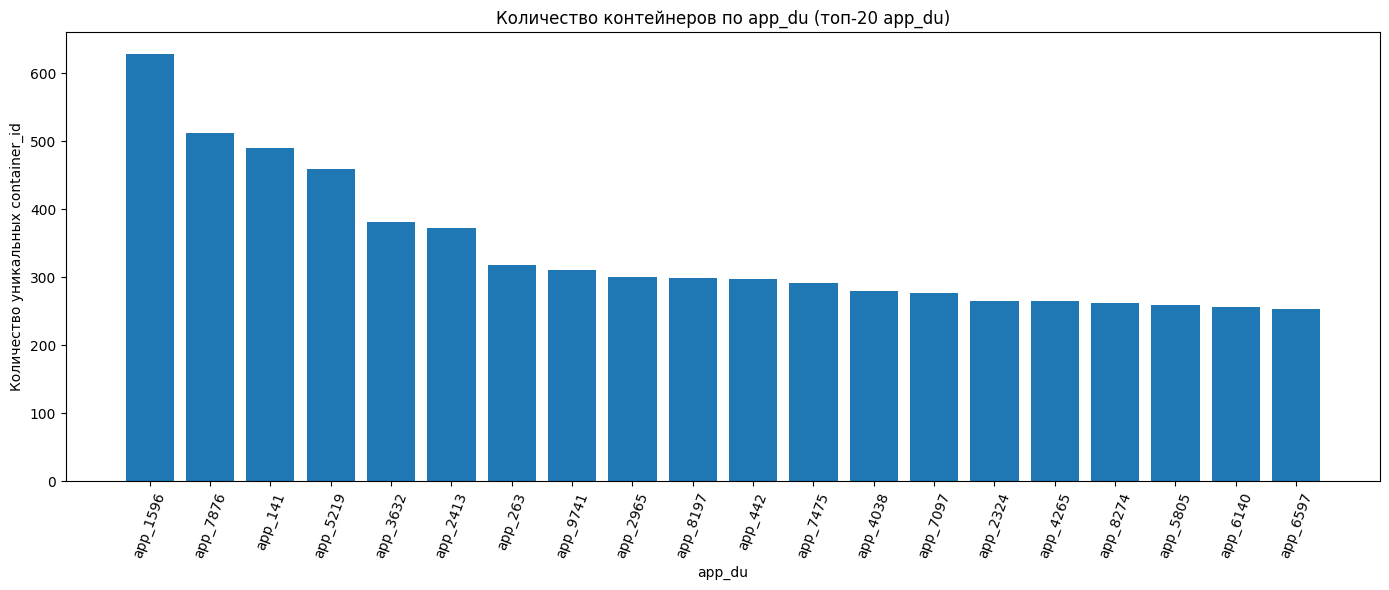

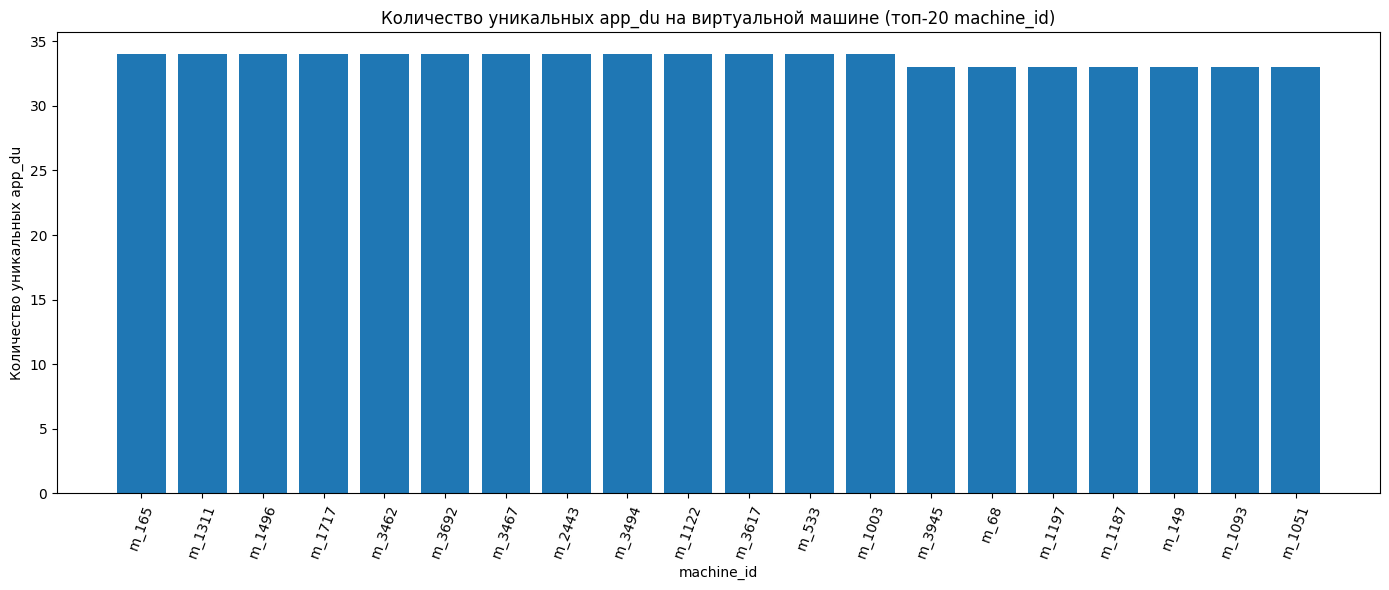

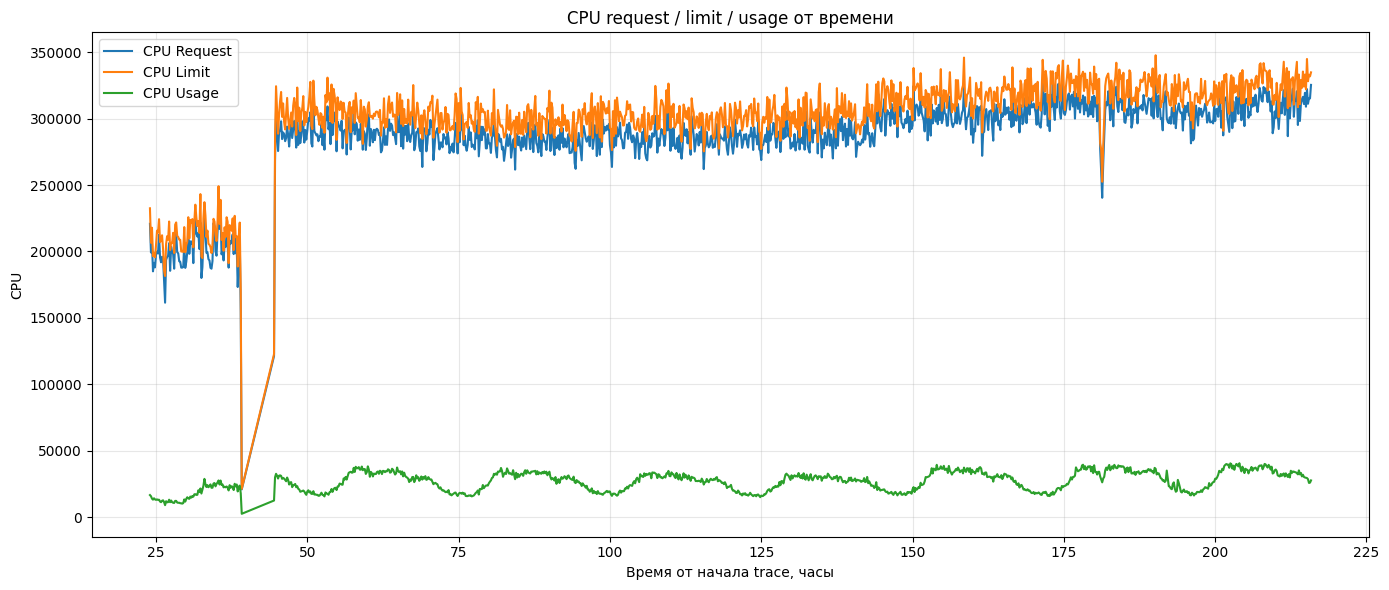

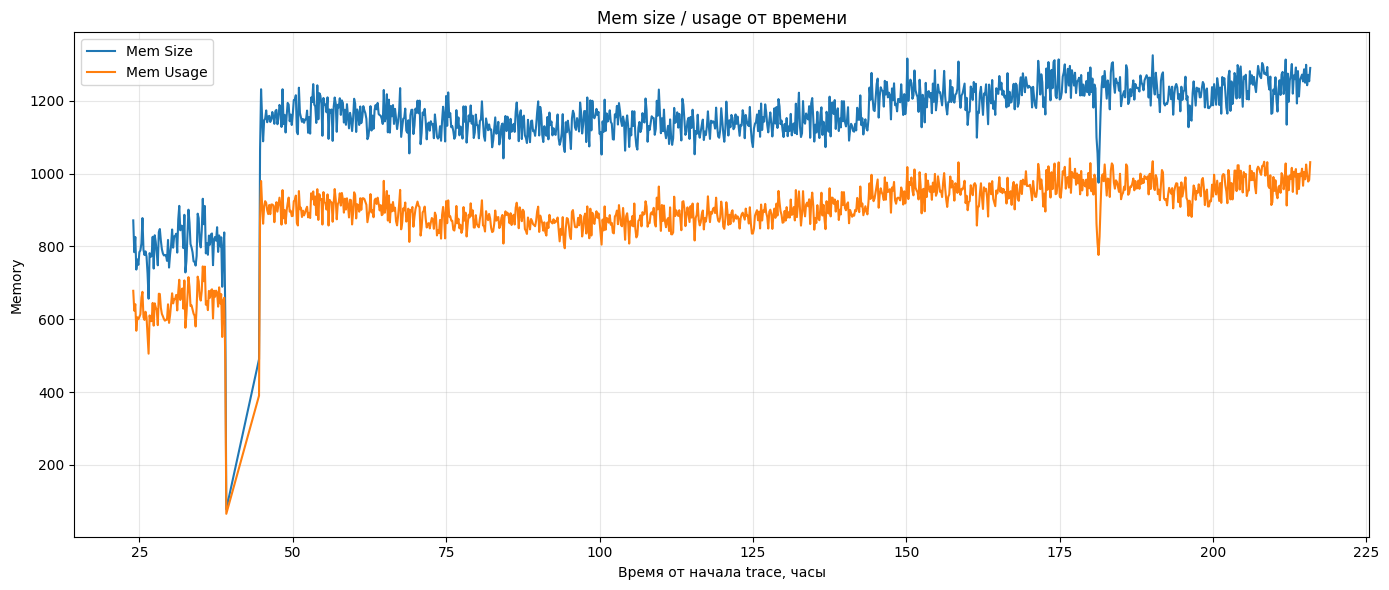

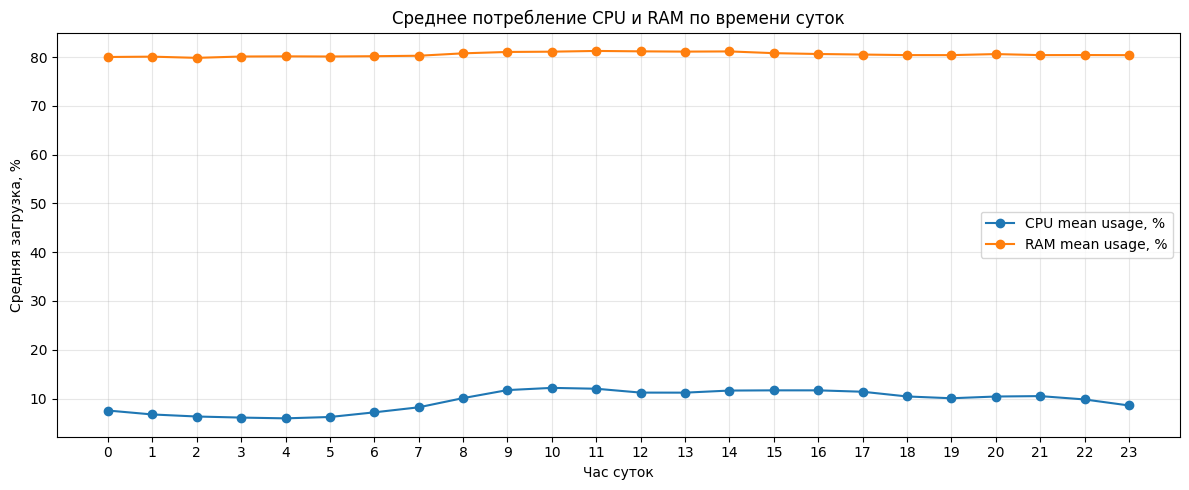

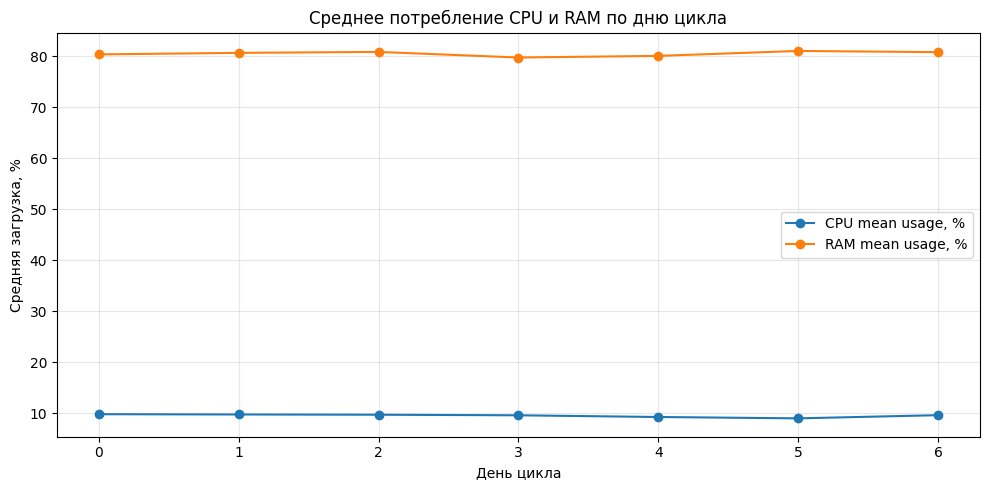

In [10]:
import matplotlib.pyplot as plt
window_df["cpu_usage_absolute"] = (window_df["cpu_util_mean"] / 100.0) * window_df["cpu_limit"]
window_df["mem_usage_absolute"] = (window_df["mem_util_mean"] / 100.0) * window_df["mem_size"]
window_df["time_window_hours"] = window_df["time_window"] / 3600.0
meta_app_unique = meta[["container_id", "app_du"]].drop_duplicates().copy()

app_container_counts = (
    meta_app_unique
    .groupby("app_du")["container_id"]
    .nunique()
    .sort_values(ascending=False)
)

max_categories_to_show = 20

if len(app_container_counts) <= max_categories_to_show:
    app_plot_counts = app_container_counts.copy()
    app_title_suffix = "все app_du"
else:
    app_plot_counts = app_container_counts.head(max_categories_to_show).copy()
    app_title_suffix = f"топ-{max_categories_to_show} app_du"

plt.figure(figsize=(14, 6))
plt.bar(app_plot_counts.index.astype(str), app_plot_counts.values)
plt.title(f"Количество контейнеров по app_du ({app_title_suffix})")
plt.xlabel("app_du")
plt.ylabel("Количество уникальных container_id")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()
meta_machine_app_unique = meta[["machine_id", "app_du"]].drop_duplicates().copy()

machine_app_counts = (
    meta_machine_app_unique
    .groupby("machine_id")["app_du"]
    .nunique()
    .sort_values(ascending=False)
)

if len(machine_app_counts) <= max_categories_to_show:
    machine_plot_counts = machine_app_counts.copy()
    machine_title_suffix = "все machine_id"
else:
    machine_plot_counts = machine_app_counts.head(max_categories_to_show).copy()
    machine_title_suffix = f"топ-{max_categories_to_show} machine_id"

plt.figure(figsize=(14, 6))
plt.bar(machine_plot_counts.index.astype(str), machine_plot_counts.values)
plt.title(f"Количество уникальных app_du на виртуальной машине ({machine_title_suffix})")
plt.xlabel("machine_id")
plt.ylabel("Количество уникальных app_du")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()
cluster_cpu_over_time = (
    window_df
    .groupby("time_window_hours", as_index=False)
    .agg(
        cpu_request_total=("cpu_request", "sum"),
        cpu_limit_total=("cpu_limit", "sum"),
        cpu_usage_total=("cpu_usage_absolute", "sum")
    )
    .sort_values("time_window_hours")
)

plt.figure(figsize=(14, 6))
plt.plot(cluster_cpu_over_time["time_window_hours"], cluster_cpu_over_time["cpu_request_total"], label="CPU Request")
plt.plot(cluster_cpu_over_time["time_window_hours"], cluster_cpu_over_time["cpu_limit_total"], label="CPU Limit")
plt.plot(cluster_cpu_over_time["time_window_hours"], cluster_cpu_over_time["cpu_usage_total"], label="CPU Usage")
plt.title("CPU request / limit / usage от времени")
plt.xlabel("Время от начала trace, часы")
plt.ylabel("CPU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
cluster_mem_over_time = (
    window_df
    .groupby("time_window_hours", as_index=False)
    .agg(
        mem_size_total=("mem_size", "sum"),
        mem_usage_total=("mem_usage_absolute", "sum")
    )
    .sort_values("time_window_hours")
)

plt.figure(figsize=(14, 6))
plt.plot(cluster_mem_over_time["time_window_hours"], cluster_mem_over_time["mem_size_total"], label="Mem Size")
plt.plot(cluster_mem_over_time["time_window_hours"], cluster_mem_over_time["mem_usage_total"], label="Mem Usage")
plt.title("Mem size / usage от времени")
plt.xlabel("Время от начала trace, часы")
plt.ylabel("Memory")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
resource_by_hour = (
    window_df
    .groupby("relative_hour", as_index=False)
    .agg(
        cpu_util_mean_avg=("cpu_util_mean", "mean"),
        mem_util_mean_avg=("mem_util_mean", "mean")
    )
    .sort_values("relative_hour")
)

plt.figure(figsize=(12, 5))
plt.plot(resource_by_hour["relative_hour"], resource_by_hour["cpu_util_mean_avg"], marker="o", label="CPU mean usage, %")
plt.plot(resource_by_hour["relative_hour"], resource_by_hour["mem_util_mean_avg"], marker="o", label="RAM mean usage, %")
plt.title("Среднее потребление CPU и RAM по времени суток")
plt.xlabel("Час суток")
plt.ylabel("Средняя загрузка, %")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
resource_by_day = (
    window_df
    .groupby("relative_day_cycle", as_index=False)
    .agg(
        cpu_util_mean_avg=("cpu_util_mean", "mean"),
        mem_util_mean_avg=("mem_util_mean", "mean")
    )
    .sort_values("relative_day_cycle")
)

plt.figure(figsize=(10, 5))
plt.plot(resource_by_day["relative_day_cycle"], resource_by_day["cpu_util_mean_avg"], marker="o", label="CPU mean usage, %")
plt.plot(resource_by_day["relative_day_cycle"], resource_by_day["mem_util_mean_avg"], marker="o", label="RAM mean usage, %")
plt.title("Среднее потребление CPU и RAM по дню цикла")
plt.xlabel("День цикла")
plt.ylabel("Средняя загрузка, %")
plt.xticks(range(0, 7))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()